# Seedmix contamination test — frequency distributions

Per-ecotype frequencies from hapFIRE-1141 on the SEEDMIX samples (S1-S3 fully complete; S4 partial).

Two colored populations:
- **in-231** (blue): the 231 GrENE-Net founders supposedly in the seedmix
- **non-231** (red): the 910 1001G accessions NOT in the GrENE-Net 231 — mass on these is potentially contamination

Reference line: `1/231 ≈ 0.00433` (uniform-recipe expected mass per founder).

Frequencies are RAW (no scale factor). Numbers span ~1e-5 to ~1e-2 so log-x is used where helpful.

**Note on hapFIRE coarseness:** at F=1141, the CompleteLDPartition only finds 1-3 coarse blocks per chrom (vs 13 across the genome in xwu's F=231 run). With single-block-per-chrom, CVXPY identifiability slack is large — expect the 60% non-231 mass to be diffuse spillover onto 1001G LD-twins of GrENE founders rather than real contamination.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = '/home/tbellagio/scratch/hapfire_sv/contamination_test'

ours = pd.read_csv(f'{ROOT}/results/per_sample_ecotype_freq_1141.tsv', sep='\t', index_col=0)
ours.index = ours.index.astype(str)
grene231 = set(open('/home/tbellagio/scratch/hapfire_sv/data/vcf_samples_231.txt').read().split())
ours['group'] = np.where(ours.index.isin(grene231), 'in231', 'non231')
samples = [c for c in ours.columns if c.startswith('SEEDMIX_')]

REF = 1.0 / 231  # 0.00433 -- uniform recipe

print(f'samples: {samples}')
print(f'in-231: {(ours.group == "in231").sum()}, non-231: {(ours.group == "non231").sum()}')
print(f'reference 1/231 = {REF:.5f}')

samples: ['SEEDMIX_S1', 'SEEDMIX_S2', 'SEEDMIX_S3']
in-231: 231, non-231: 910
reference 1/231 = 0.00433


## Per-sample summary (raw frequencies)

In [2]:
rows = []
for s in samples:
    in231 = ours.loc[ours.group=='in231', s]
    non231 = ours.loc[ours.group=='non231', s]
    rows.append({
        'sample': s,
        'in231_sum': in231.sum(),
        'in231_mean': in231.mean(),
        'in231_med': in231.median(),
        'in231_max': in231.max(),
        'non231_sum': non231.sum(),
        'non231_mean': non231.mean(),
        'non231_med': non231.median(),
        'non231_max': non231.max(),
    })
summary = pd.DataFrame(rows)
summary.style.format(precision=5)

,sample,in231_sum,in231_mean,in231_med,in231_max,non231_sum,non231_mean,non231_med,non231_max
0,SEEDMIX_S1,0.40152,0.00174,0.00138,0.00841,0.59849,0.00066,0.00062,0.00687
1,SEEDMIX_S2,0.40284,0.00174,0.00140,0.00937,0.59717,0.00066,0.00063,0.00675
2,SEEDMIX_S3,0.41192,0.00178,0.00137,0.01406,0.58807,0.00065,0.00060,0.00522


## Distribution overlay — log x-axis (best when values span many orders of magnitude)

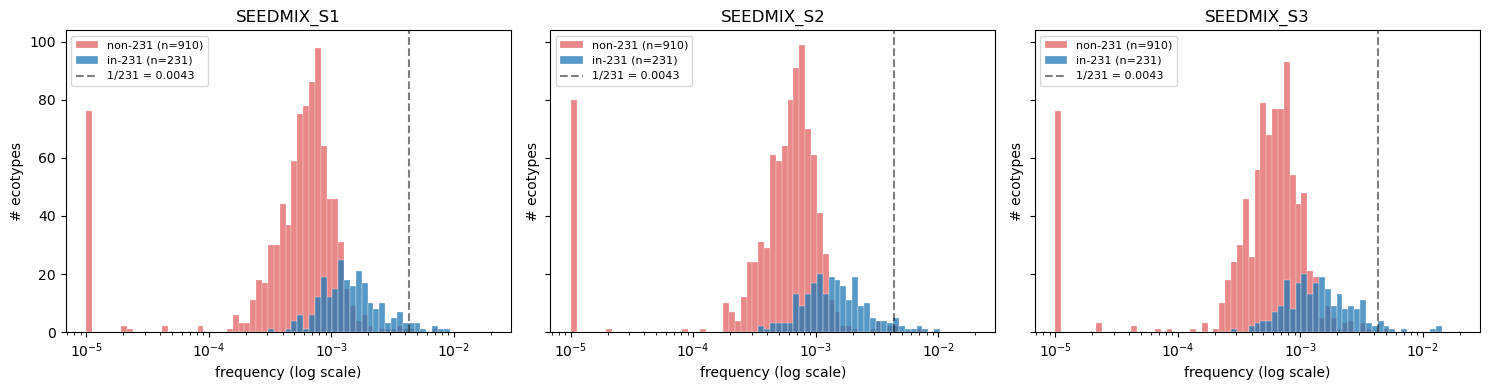

saved: results/dist_log.png


In [3]:
n = len(samples)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4), sharey=True)
if n == 1: axes = [axes]

log_bins = np.logspace(-5, -1.7, 70)  # 1e-5 to ~2e-2

for ax, s in zip(axes, samples):
    in231 = ours.loc[ours.group=='in231', s]
    non231 = ours.loc[ours.group=='non231', s]
    in231_c = in231.clip(lower=1e-5)
    non231_c = non231.clip(lower=1e-5)
    ax.hist(non231_c, bins=log_bins, alpha=0.55, color='#d62728', label='non-231 (n=910)', edgecolor='white', linewidth=0.3)
    ax.hist(in231_c,  bins=log_bins, alpha=0.75, color='#1f77b4', label='in-231 (n=231)',  edgecolor='white', linewidth=0.3)
    ax.axvline(REF, color='black', linestyle='--', alpha=0.5, label=f'1/231 = {REF:.4f}')
    ax.set_xscale('log')
    ax.set_xlabel('frequency (log scale)')
    ax.set_ylabel('# ecotypes')
    ax.set_title(s)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{ROOT}/results/dist_log.png', dpi=140, bbox_inches='tight')
plt.show()
print('saved: results/dist_log.png')

## Distribution overlay — linear x-axis

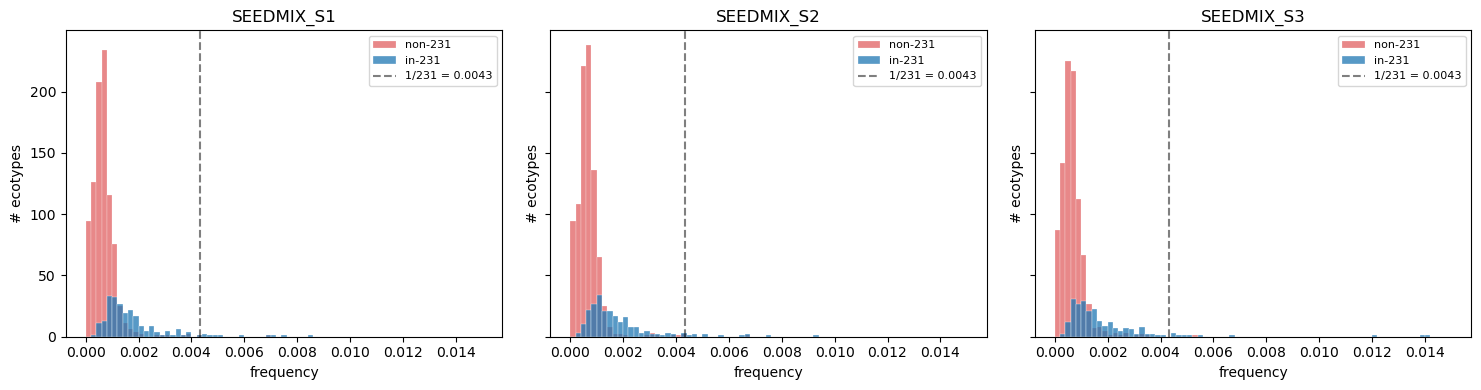

saved: results/dist_linear.png


In [4]:
fig, axes = plt.subplots(1, n, figsize=(5*n, 4), sharey=True)
if n == 1: axes = [axes]

lin_bins = np.linspace(0, 0.015, 76)

for ax, s in zip(axes, samples):
    in231 = ours.loc[ours.group=='in231', s]
    non231 = ours.loc[ours.group=='non231', s]
    ax.hist(non231, bins=lin_bins, alpha=0.55, color='#d62728', label='non-231', edgecolor='white', linewidth=0.3)
    ax.hist(in231,  bins=lin_bins, alpha=0.75, color='#1f77b4', label='in-231',  edgecolor='white', linewidth=0.3)
    ax.axvline(REF, color='black', linestyle='--', alpha=0.5, label=f'1/231 = {REF:.4f}')
    ax.set_xlabel('frequency')
    ax.set_ylabel('# ecotypes')
    ax.set_title(s)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{ROOT}/results/dist_linear.png', dpi=140, bbox_inches='tight')
plt.show()
print('saved: results/dist_linear.png')

## Empirical CDF — cleanest visual

What fraction of ecotypes (within each group) have mass below a given threshold? In a clean seedmix with a perfect estimator, the non-231 (red) curve would be a step at 0 and the in-231 (blue) curve would be a step at 1/231.

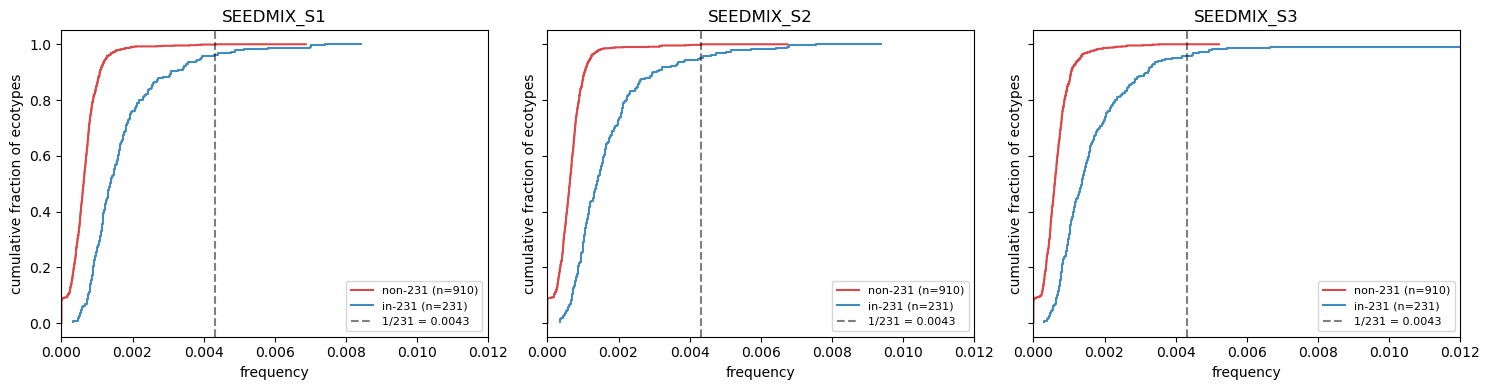

saved: results/ecdf.png


In [5]:
fig, axes = plt.subplots(1, n, figsize=(5*n, 4), sharey=True)
if n == 1: axes = [axes]

for ax, s in zip(axes, samples):
    in231 = np.sort(ours.loc[ours.group=='in231', s].values)
    non231 = np.sort(ours.loc[ours.group=='non231', s].values)
    in_e  = np.arange(1, len(in231)+1) / len(in231)
    non_e = np.arange(1, len(non231)+1) / len(non231)
    ax.step(non231, non_e, color='#d62728', alpha=0.85, label='non-231 (n=910)')
    ax.step(in231,  in_e,  color='#1f77b4', alpha=0.85, label='in-231 (n=231)')
    ax.axvline(REF, color='black', linestyle='--', alpha=0.5, label=f'1/231 = {REF:.4f}')
    ax.set_xlabel('frequency')
    ax.set_ylabel('cumulative fraction of ecotypes')
    ax.set_title(s)
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xlim(0, 0.012)

plt.tight_layout()
plt.savefig(f'{ROOT}/results/ecdf.png', dpi=140, bbox_inches='tight')
plt.show()
print('saved: results/ecdf.png')

## Cross-sample combined histogram (linear + log)

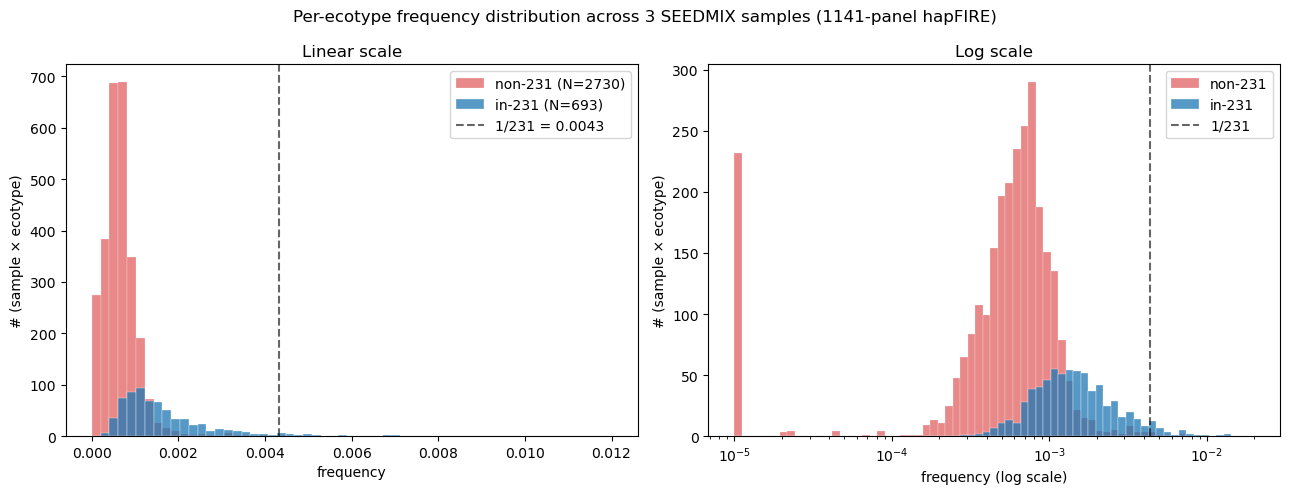

saved: results/dist_combined.png

in-231:  median 0.00138, 90th pct 0.00320, max 0.01406
non-231: median 0.00062, 90th pct 0.00107, max 0.00687


In [6]:
all_in = np.concatenate([ours.loc[ours.group=='in231', s].values for s in samples])
all_non = np.concatenate([ours.loc[ours.group=='non231', s].values for s in samples])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
lin_bins = np.linspace(0, 0.012, 60)
ax.hist(all_non, bins=lin_bins, alpha=0.55, color='#d62728', label=f'non-231 (N={len(all_non)})', edgecolor='white', linewidth=0.3)
ax.hist(all_in,  bins=lin_bins, alpha=0.75, color='#1f77b4', label=f'in-231 (N={len(all_in)})',  edgecolor='white', linewidth=0.3)
ax.axvline(REF, color='black', linestyle='--', alpha=0.6, label=f'1/231 = {REF:.4f}')
ax.set_xlabel('frequency')
ax.set_ylabel('# (sample × ecotype)')
ax.set_title('Linear scale')
ax.legend()

ax = axes[1]
log_bins = np.logspace(-5, -1.7, 70)
all_in_c = np.clip(all_in, 1e-5, None)
all_non_c = np.clip(all_non, 1e-5, None)
ax.hist(all_non_c, bins=log_bins, alpha=0.55, color='#d62728', label='non-231', edgecolor='white', linewidth=0.3)
ax.hist(all_in_c,  bins=log_bins, alpha=0.75, color='#1f77b4', label='in-231',  edgecolor='white', linewidth=0.3)
ax.axvline(REF, color='black', linestyle='--', alpha=0.6, label='1/231')
ax.set_xscale('log')
ax.set_xlabel('frequency (log scale)')
ax.set_ylabel('# (sample × ecotype)')
ax.set_title('Log scale')
ax.legend()

fig.suptitle(f'Per-ecotype frequency distribution across {len(samples)} SEEDMIX samples (1141-panel hapFIRE)')
plt.tight_layout()
plt.savefig(f'{ROOT}/results/dist_combined.png', dpi=140, bbox_inches='tight')
plt.show()
print('saved: results/dist_combined.png')
print()
print(f'in-231:  median {np.median(all_in):.5f}, 90th pct {np.percentile(all_in, 90):.5f}, max {all_in.max():.5f}')
print(f'non-231: median {np.median(all_non):.5f}, 90th pct {np.percentile(all_non, 90):.5f}, max {all_non.max():.5f}')

## Top non-231 ecotypes by mean mass

Real contamination would show as concentrated mass on a few specific accessions. We see all top non-231 ecotypes at <1% mass each — highly diffuse — consistent with CVXPY identifiability spillover at F=1141, not contamination.

In [7]:
top = pd.read_csv(f'{ROOT}/results/non231_top.tsv', sep='\t', index_col=0)
print('Top 25 non-231 ecotypes by mean mass (raw frequency):')
top.head(25).style.format(precision=5)

Top 25 non-231 ecotypes by mean mass (raw frequency):


,SEEDMIX_S1,SEEDMIX_S2,SEEDMIX_S3,mean_mass,max_mass
ecotype,,,,,
6909,0.00687,0.00675,0.00522,0.00628,0.00687
7461,0.00435,0.00431,0.00336,0.00401,0.00435
5104,0.00382,0.00434,0.00354,0.00390,0.00434
7208,0.00392,0.00401,0.00309,0.00367,0.00401
5486,0.00317,0.00388,0.00332,0.00346,0.00388
8239,0.00360,0.00321,0.00248,0.00310,0.00360
9996,0.00284,0.00283,0.00229,0.00266,0.00284
6434,0.00195,0.00319,0.00264,0.00259,0.00319
7096,0.00195,0.00316,0.00262,0.00258,0.00316
